In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as lr 
from sklearn.linear_model import Lasso
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import combinations

## Data:

In [80]:
# Load Data:
path_train = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\raw\synthetic_dataset_A_non-iid.csv"
df = pd.read_csv(path_train)

path_test = r"C:\Users\oskar\OneDrive\Desktop\4 Semester\Dataproject\Federated-dental-risk-vol2\federated-dental-risk-prediction\data\processed\A\global_test_set_non-iid.csv"
test_data = pd.read_csv(path_test)

# Define variabels:
variables = df.columns[2:27].tolist()

X_train = df[variables].copy()
X_test = test_data[variables].copy()

# Function for interaktions:
def add_interactions(X, variables):
    interaction_cols = {}

    for v1, v2 in combinations(variables, 2):
        interaction_cols[f"{v1}_x_{v2}"] = X[v1] * X[v2]

    interaction_df = pd.DataFrame(interaction_cols, index=X.index)

    return pd.concat([X, interaction_df], axis=1)

#Add interactions
train_design_df = add_interactions(X_train, variables)
test_design_df = add_interactions(X_test, variables)

# Sørg for samme kolonner (meget vigtigt!)
test_design_df = test_design_df[train_design_df.columns]


# Standardise
scaler = StandardScaler()

train_design = pd.DataFrame(
    scaler.fit_transform(train_design_df),
    columns=train_design_df.columns,
    index=train_design_df.index
)

test_design = pd.DataFrame(
    scaler.transform(test_design_df),
    columns=test_design_df.columns,
    index=test_design_df.index
)

## Functions:

In [81]:
def predict_and_group_centralized(test_df, variables, models):
    """
    Laver predictions og kvatil-grupper for hver complication på test_df.
    
    Tilføjer for hver complication:
      - Risk_XXX_group
    
    Returnerer:
      out_df, cutoffs
    """
    out = test_df.copy()
    cutoffs = {}

    n = len(test_df)
    d = len(variables)

    X_test = np.zeros((n, d))
    for i in range(d):
        X_test[:, i] = test_df[variables[i]]

    for complication, params in models.items():
        intercept = params["intercept"]
        coefs = params["coef"]

        y_hat = intercept + X_test @ coefs

        q1 = np.quantile(y_hat, 1/3)
        q2 = np.quantile(y_hat, 2/3)

        groups = np.where(
            y_hat <= q1, 0,
            np.where(y_hat <= q2, 1, 2)
        )

        out[f"{complication}_group"] = groups

        cutoffs[complication] = {
            "q1": q1,
            "q2": q2
        }

    return out, cutoffs

def fit_centralized_models_lasso(train_df, variables, complications, lam):
    """
    Fitter én lineær regression pr. complication.
    """
    models = {}

    n = len(train_df)
    d = len(variables)

    X_train = np.zeros((n, d))
    for i in range(d):
        X_train[:, i] = train_df[variables[i]]

    for complication in complications:
        y_train = train_df[complication].to_numpy()

        model = Lasso(alpha=lam, max_iter=10000)
        model.fit(X_train, y_train)

        models[complication] = {
            "intercept": model.intercept_,
            "coef": model.coef_
        }

    return models


def tune_lasso_lambda(train_df, test_df, variables, complications, lambdas):
    results = []

    X_train = train_df[variables].to_numpy()

    for lam in lambdas:
        models = {}

        # fit model for each complication
        for complication in complications:
            y_train = train_df[complication].to_numpy()

            model = Lasso(alpha=lam, max_iter=10000)
            model.fit(X_train, y_train)

            models[complication] = {
                "intercept": model.intercept_,
                "coef": model.coef_
            }

        # predict + group
        test_with_preds, _ = predict_and_group_centralized(test_df, variables, models)

        # EGEN metrics (robust version)
        macro_f1s = []

        for complication in complications:
            true_col = complication.replace("Risk_", "Risk_Category_", 1)
            pred_col = f"{complication}_group"

            y_true = test_with_preds[true_col].to_numpy().ravel()
            y_pred = test_with_preds[pred_col].to_numpy().ravel()

            f1s = []

            for cls in [0, 1, 2]:
                tp = np.sum((y_true == cls) & (y_pred == cls))
                fp = np.sum((y_true != cls) & (y_pred == cls))
                fn = np.sum((y_true == cls) & (y_pred != cls))

                precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

                f1 = (
                    2 * precision * recall / (precision + recall)
                    if (precision + recall) > 0 else 0.0
                )

                f1s.append(f1)

            macro_f1s.append(np.mean(f1s))

        overall_f1 = np.mean(macro_f1s)

        results.append((lam, overall_f1))

        print(f"lambda={lam:.5f} -> F1={overall_f1:.4f}")

    return results

def metrics_for_one_complication(y_true, y_pred):
    """
    complication fx 'Risk_AlveolarOsteitis'
    
    Bruger:
      true: Risk_Category_AlveolarOsteitis
      pred: Risk_AlveolarOsteitis_group
    """
    
    results = {}
    
    for cls in [0, 1, 2]:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        results[cls] = {
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }
    
    macro_f1 = np.mean([results[cls]["f1"] for cls in [0, 1, 2]])
    
    return {
        "per_class": results,
        "macro_f1": macro_f1
    }

def predict_from_coefs(df, variables, intercept, coefs):
    """
    Beregner y-hat = intercept + X beta
    for alle rækker i df.
    """
    X = df[variables].to_numpy()
    y_hat = intercept + X @ coefs
    return y_hat

def assign_tertiles(y_hat):
    """
    Deler y_hat i 3 grupper baseret på 1/3 og 2/3 kvantiler.
    Returnerer både gruppe-labels og grænserne.
    """
    q1 = np.quantile(y_hat, 1/3)
    q2 = np.quantile(y_hat, 2/3)

    groups = np.where(
        y_hat <= q1, 0,
        np.where(y_hat <= q2, 1, 2)
    )

    return groups, q1, q2

def name_of_features(coefs, variabels):
    idx = []
    for i in range(len(coefs)):
        if coefs[i] > 0:
            idx.append(i)
    
    return [variabels[i] for i in idx]

## Results:

We run the lasso regression with lambda = 0.004328, based on the sweep in the bottum of the document.

In [82]:
base_variables = train_design.columns.tolist()

train_design["Risk_AlveolarOsteitis"] = df["Risk_AlveolarOsteitis"]
train_design["Risk_Category_AlveolarOsteitis"] = df["Risk_Category_AlveolarOsteitis"]
test_design["Risk_AlveolarOsteitis"] = test_data["Risk_AlveolarOsteitis"]
test_design["Risk_Category_AlveolarOsteitis"] = test_data["Risk_Category_AlveolarOsteitis"]

centralized_lasso = fit_centralized_models_lasso(train_design, base_variables, ["Risk_AlveolarOsteitis"], lam = 0.004328)

centralized_lasso_names = name_of_features(centralized_lasso["Risk_AlveolarOsteitis"].get("coef"), base_variables)
centralized_lasso_names

['Age_x_Impaction_Depth',
 'Age_x_Proximity_Nerve',
 'Age_x_Surgical_Extraction_Type',
 'Trismus_x_Proximity_Nerve',
 'Pericoronitis_x_Impaction_Depth',
 'Pericoronitis_x_Proximity_Nerve',
 'Impaction_Depth_x_Proximity_Nerve',
 'Impaction_Depth_x_Surgical_Extraction_Type']

In [83]:
base_variables = [
    col for col in train_design.columns
    if col not in ["Patient", "Client", "Risk_AlveolarOsteitis", "Risk_Category_AlveolarOsteitis"]
]

inter = centralized_lasso["Risk_AlveolarOsteitis"]["intercept"]
coefs = centralized_lasso["Risk_AlveolarOsteitis"]["coef"].tolist()

preds = predict_from_coefs(test_design, base_variables, inter, coefs)
cat_pred, a, b = assign_tertiles(preds)

y_true = test_data["Risk_Category_AlveolarOsteitis"].values
y_pred = cat_pred

metrics_for_one_complication(y_true, y_pred)

{'per_class': {0: {'TP': np.int64(796),
   'FP': np.int64(212),
   'FN': np.int64(169),
   'precision': np.float64(0.7896825396825397),
   'recall': np.float64(0.8248704663212435),
   'f1': np.float64(0.8068930562595032)},
  1: {'TP': np.int64(559),
   'FP': np.int64(433),
   'FN': np.int64(468),
   'precision': np.float64(0.563508064516129),
   'recall': np.float64(0.5443037974683544),
   'f1': np.float64(0.5537394749876176)},
  2: {'TP': np.int64(707),
   'FP': np.int64(293),
   'FN': np.int64(301),
   'precision': np.float64(0.707),
   'recall': np.float64(0.7013888888888888),
   'f1': np.float64(0.704183266932271)}},
 'macro_f1': np.float64(0.6882719327264639)}

We achive the best performance yet. 
The below code tries 100 different lambdas on a small subset:

In [84]:
#train_design = train_design[:2500]
#test_design = test_design

lambdas = np.logspace(-5, 0, 20)  
results = tune_lasso_lambda(
    train_df=train_design,
    test_df=test_design,
    variables = base_variables,
    complications=["Risk_AlveolarOsteitis"],
    lambdas=lambdas
)

lambda=0.00001 -> F1=0.6445
lambda=0.00002 -> F1=0.6455
lambda=0.00003 -> F1=0.6459
lambda=0.00006 -> F1=0.6505
lambda=0.00011 -> F1=0.6535
lambda=0.00021 -> F1=0.6585
lambda=0.00038 -> F1=0.6605
lambda=0.00070 -> F1=0.6722
lambda=0.00127 -> F1=0.6715
lambda=0.00234 -> F1=0.6822
lambda=0.00428 -> F1=0.6859
lambda=0.00785 -> F1=0.6857
lambda=0.01438 -> F1=0.6319
lambda=0.02637 -> F1=0.6740
lambda=0.04833 -> F1=0.1623
lambda=0.08859 -> F1=0.1623
lambda=0.16238 -> F1=0.1623
lambda=0.29764 -> F1=0.1623
lambda=0.54556 -> F1=0.1623
lambda=1.00000 -> F1=0.1623


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
C:\Users\oskar\AppData\Local\Temp\ipykernel_23084\1308858832.py:10: SyntaxWarning: invalid escape sequence '\l'
  plt.title("F1 score across $\lambda$'s in LASSO")
C:\Users\oskar\AppData\Local\Temp\ipykernel_23084\1308858832.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax.axvline(x=max_lambda, linestyle=':', color='black', label = "Optimal $\lambda$")


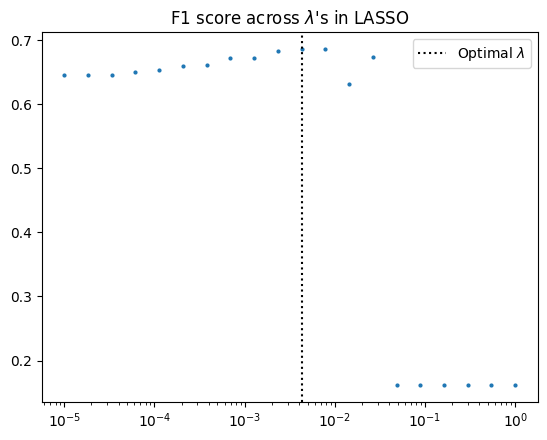

In [85]:
results = np.array(results).T

idx = np.argmax(results[1])
max_F1 = max(results[1])
max_lambda = results[0, idx]

fig, ax = plt.subplots()
ax.plot(results[0], results[1], "o", markersize = 2)
plt.xscale('log')
plt.title("F1 score across $\lambda$'s in LASSO")
ax.axvline(x=max_lambda, linestyle=':', color='black', label = "Optimal $\lambda$")
plt.legend()